# In-Class Exercise on Spam Filtering  
In this exercise, we will use powerful tools such as pandas and sklearn to distinguish between spam and regular emails based on the information contained in the emails themselves.


## Download Data  
The data is downloaded using gdown into the same folder as the current file. After downloading, we unzip the received data.

In [2]:
#### YOUR CODE HERE ####import io
import gdown
import zipfile
import os

def download_and_unzip(file_id, output_zip, extract_dir="."):
    # Download file from Google Drive
    url = f"https://drive.google.com/uc?id={file_id}"
    print(f"Downloading from {url} ...")
    gdown.download(url, output_zip, quiet=False)

    # Upzip file and remove zip file after unzipping
    with zipfile.ZipFile(output_zip, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print(f"Unzipped to {extract_dir}")

    os.remove(output_zip)
    print("Removed zip file")


data_dir = "./data"
if not os.path.exists(data_dir):
    os.makedirs(data_dir)
    
file_id = "1bTJKchSInd3IgLs41b1_-Gd-T36a_pal"   # ID from Google Drive
download_and_unzip(file_id, "downloaded_file.zip", "./data")

#### END YOUR CODE #####

Downloading...
From: https://drive.google.com/uc?id=1bTJKchSInd3IgLs41b1_-Gd-T36a_pal
To: /mnt/e/Development/Python/NLP/NaturalLanguageProcessing/VectorSemanticAndEmbedding/downloaded_file.zip
100%|██████████| 1.95M/1.95M [00:00<00:00, 5.45MB/s]


Unzipped to ./data
Removed zip file


## Using Pandas for Storage  
Pandas is a commonly used library for storing data utilized in machine learning processes, offering functions suitable for large datasets and high performance. We read the data from the unzipped file into a `DataFrame`.


In [3]:
#### YOUR CODE HERE ####
import pandas as pd
import os

data_path = os.path.join(data_dir, "spam_ham_dataset.csv")
if os.path.exists(data_path):
    df = pd.read_csv(data_path)
else:
    print(f"File {data_path} not found!")
#### END YOUR CODE #####

Visualizing Data with 5 Examples 

In [4]:
#### YOUR CODE HERE ####
print(df.head(5))
#### END YOUR CODE #####

   Unnamed: 0 label                                               text  \
0         605   ham  Subject: enron methanol ; meter # : 988291\r\n...   
1        2349   ham  Subject: hpl nom for january 9 , 2001\r\n( see...   
2        3624   ham  Subject: neon retreat\r\nho ho ho , we ' re ar...   
3        4685  spam  Subject: photoshop , windows , office . cheap ...   
4        2030   ham  Subject: re : indian springs\r\nthis deal is t...   

   label_num  
0          0  
1          0  
2          0  
3          1  
4          0  


## Data Preprocessing  
As we can see, the current data contains Windows newline characters `\r\n`, which may cause confusion. To simplify, we replace them with spaces. You can also apply additional Pandas methods (e.g., removing the "Subject:" prefix, extracting the first line, etc.).


In [5]:
#### YOUR CODE HERE ####
import re
def preprocessing_data(data_frame):
    df = data_frame.copy()
    
    # Normalize newlines
    df["text"] = df["text"].str.replace(r"\r\n|\r", "\n", regex=True)
    
    # Extract subject line before modifying text
    df["subject"] = df["text"].str.extract(r"^subject:\s*(.*)", flags=re.IGNORECASE)
    
    # Remove the subject line from body text
    df["body"] = df["text"].str.replace(r"^subject:.*\n?", "", regex=True, flags=re.IGNORECASE)
    
    # Convert to lowercase
    df["subject"] = df["subject"].str.lower()
    df["body"] = df["body"].str.lower()
    
    # Replace URLs and email addresses with placeholders
    df["subject"] = df["subject"].str.replace(r"http\S+|www\S+|https\S+", " <url> ", regex=True)
    df["body"] = df["body"].str.replace(r"http\S+|www\S+|https\S+", " <url> ", regex=True)
    
    df["subject"] = df["subject"].str.replace(r"\S+@\S+", " <email> ", regex=True)
    df["body"] = df["body"].str.replace(r"\S+@\S+", " <email> ", regex=True)

    # Replace numbers with placeholder
    df["subject"] = df["subject"].str.replace(r"\d+", " <num> ", regex=True)
    df["body"] = df["body"].str.replace(r"\d+", " <num> ", regex=True)
    
    # Strip the spaces
    df["subject"] = df["subject"].str.replace(r"\s+", " ", regex=True).str.strip()
    df["body"] = df["body"].str.replace(r"\s+", " ", regex=True).str.strip()
    
    # Combine subject and body into clean_text
    df["clean_text"] = df["subject"] + " " + df["body"]
    
    return df

df_processed = preprocessing_data(df)
print(df_processed[["subject","body","clean_text"]].head(5))
#### END YOUR CODE #####


                                             subject  \
0                   enron methanol ; meter # : <num>   
1                  hpl nom for january <num> , <num>   
2                                       neon retreat   
3  photoshop , windows , office . cheap . main tr...   
4                                re : indian springs   

                                                body  \
0  this is a follow up to the note i gave you on ...   
1  ( see attached file : hplnol <num> . xls ) - h...   
2  ho ho ho , we ' re around to that most wonderf...   
3  abasements darer prudently fortuitous undergon...   
4  this deal is to book the teco pvr revenue . it...   

                                          clean_text  
0  enron methanol ; meter # : <num> this is a fol...  
1  hpl nom for january <num> , <num> ( see attach...  
2  neon retreat ho ho ho , we ' re around to that...  
3  photoshop , windows , office . cheap . main tr...  
4  re : indian springs this deal is to book the t..

## Building Model  
First, we perform vectorization of the input data using `CountVectorizer`, aiming to convert text data into numerical representations. `CountVectorizer` creates a vocabulary of words appearing in the dataset and generates a corresponding vector for each sample, representing the word frequencies within that sample.


In [6]:
from sklearn.feature_extraction.text import CountVectorizer
#### YOUR CODE HERE ####
def vectorize_text(df, column="text"):
    vectorizer = CountVectorizer()
    X = vectorizer.fit_transform(df[column])
    return X, vectorizer

X, vectorizer = vectorize_text(df_processed, column="clean_text")
print("Shape of vectorized data:", X.shape)
# print("Feature names:", vectorizer.get_feature_names_out()[:10])
# print("Sample vectorized data: ", X.toarray()[0][:10])

first_row = X[0].toarray().flatten()
indices = first_row.nonzero()[0]
for idx in indices:
    print(vectorizer.get_feature_names_out()[idx], ":", first_row[idx])

#### END YOUR CODE #####

Shape of vectorized data: (5171, 45739)
activity : 1
asap : 1
by : 1
can : 1
change : 1
control : 1
daily : 2
daren : 1
data : 1
economics : 1
enron : 1
flow : 1
follow : 1
for : 1
from : 1
gas : 1
gave : 1
is : 2
meter : 1
methanol : 1
monday : 1
needed : 1
note : 1
num : 4
obtain : 1
on : 1
override : 1
please : 1
pop : 1
preliminary : 1
presently : 1
provided : 1
purposes : 1
reflect : 1
the : 1
this : 2
to : 2
up : 1
volume : 1
you : 2
zero : 1


Next, we apply the TF-IDF algorithm to the obtained vector. The output remains a sparse matrix but is now adjusted for the rarity of each word.


In [7]:
from sklearn.feature_extraction.text import TfidfTransformer
#### YOUR CODE HERE ####
def tf_idf_transform(X):
    transformer = TfidfTransformer()
    X_tfidf = transformer.fit_transform(X)
    return X_tfidf, transformer

X_tfidf, transformer = tf_idf_transform(X)
print("Shape of TF-IDF transformed data:", X_tfidf.shape)
print("Non-zero features:", X_tfidf[0].nnz)
#### END YOUR CODE #####

Shape of TF-IDF transformed data: (5171, 45739)
Non-zero features: 41


We can generate n-gram data using the `ngram_range` argument in `CountVectorizer`, allowing the program to capture commonly occurring n-word phrases in the dataset.  

Additionally, `CountVectorizer` and `TfidfTransformer` have a combined wrapper that integrates both processes into one while accepting their shared arguments: `TfidfVectorizer`.


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

#### YOUR CODE HERE ####
def vectorize_text_tfidf(df, column="text", ngram_range=(1,2), max_features=50000):
    vectorizer = TfidfVectorizer(
        ngram_range=ngram_range,
        stop_words='english',
        token_pattern=r'[A-Za-z]+',
        max_features=max_features
    )
    X_tfidf = vectorizer.fit_transform(df[column])
    return X_tfidf, vectorizer

X_tfidf, vectorizer = vectorize_text_tfidf(df_processed, ngram_range=(1,2))
print("Shape of TF-IDF data:", X_tfidf.shape)
print("Non-zero features (doc 0):", X_tfidf[0].nnz)
print("Sample features:", vectorizer.get_feature_names_out()[:20])
#### END YOUR CODE #####


Shape of TF-IDF data: (5171, 50000)
Non-zero features (doc 0): 48
Sample features: ['aa' 'aa check' 'aalland' 'aalland aep' 'aaron' 'ab' 'aba' 'abacha'
 'aback' 'abacus' 'abacus technologies' 'abacustech' 'abacustech net'
 'abate' 'abazis' 'abb' 'abbas' 'abbot' 'abbott' 'abbott todd']


After completing the vectorization steps, we proceed to split the data into training and testing sets to evaluate the model's performance.








In [9]:
from sklearn.model_selection import train_test_split
#### YOUR CODE HERE ####
X = X_tfidf
y = df_processed["label_num"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape, X_test.shape)
#### END YOUR CODE #####

(4136, 50000) (1035, 50000)


Once we have the vectorized data, we use a Bayesian model to compute the results, such as `GaussianNB`. Other machine learning models can also be applied here (e.g., `LogisticRegression`, `SVM`).  

**Note:** The `todense()` function is used to convert a sparse matrix to a dense matrix, which may cause `MemoryError` for large datasets. Consider using models that support training with sparse matrices or implementing your own solution here.


In [10]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
#### YOUR CODE HERE ####
X_train_dense = X_train.toarray()
X_test_dense = X_test.toarray()
gnb = GaussianNB()
gnb.fit(X_train_dense, y_train)
y_pred_nb = gnb.predict(X_test_dense)

print("GaussianNB Accuracy:", accuracy_score(y_test, y_pred_nb))
print(f"Classification report: {classification_report(y_test, y_pred_nb)}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
#### END YOUR CODE #####

GaussianNB Accuracy: 0.9845410628019323
Classification report:               precision    recall  f1-score   support

           0       1.00      0.98      0.99       735
           1       0.96      0.99      0.97       300

    accuracy                           0.98      1035
   macro avg       0.98      0.99      0.98      1035
weighted avg       0.98      0.98      0.98      1035

Confusion Matrix:
 [[722  13]
 [  3 297]]


## Metrics and Visualization  
To evaluate the model's performance, we can compute the F1 score or accuracy. In this case, we use the F1 score since the class distribution in the dataset is imbalanced (with 25% spam).  

Additionally, we can plot the ROC-AUC curve to visualize different cutoff points for the model.


F1 Score: 0.9737704918032787
ROC-AUC: 0.9861564625850341


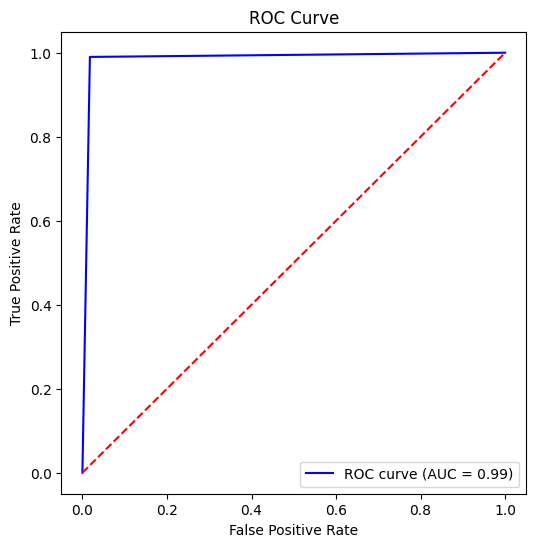

In [19]:
#### YOUR CODE HERE ####
from sklearn.metrics import f1_score, roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt

# Predictions and probabilities
y_pred_nb = gnb.predict(X_test_dense)
y_proba_nb = gnb.predict_proba(X_test_dense)[:, 1]

# F1-score
f1_nb = f1_score(y_test, y_pred_nb)
print("F1 Score:", f1_nb)

# ROC-AUC
roc_auc_nb = roc_auc_score(y_test, y_proba_nb)
print("ROC-AUC:", roc_auc_nb)

fpr_nb, tpr_nb, thresholds = roc_curve(y_test, y_proba_nb)

plt.figure(figsize=(6,6))
plt.plot(fpr_nb, tpr_nb, color="blue", label=f"ROC curve (AUC = {roc_auc_nb:.2f})")
plt.plot([0,1], [0,1], color="red", linestyle="--") 
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

#### END YOUR CODE #####

## Alternative: Co-occurrence and TruncatedSVD  

In language, semantically related words (e.g., *doctor* and *patient*) often appear in the same context. Based on this idea, we can construct a co-occurrence matrix that captures word occurrences within sentences. This allows us to represent words in a shared vector space rather than relying on simple frequency counts.  

A co-occurrence matrix with a window spanning the entire sentence can be built using the existing `CountVectorizer` data or manually constructed.


F1 score: 0.94
ROC-AUC: 0.9918684807256236

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       735
           1       0.94      0.94      0.94       300

    accuracy                           0.97      1035
   macro avg       0.96      0.96      0.96      1035
weighted avg       0.97      0.97      0.97      1035



/home/dikhang_hcmut/miniconda3/envs/pytorch_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


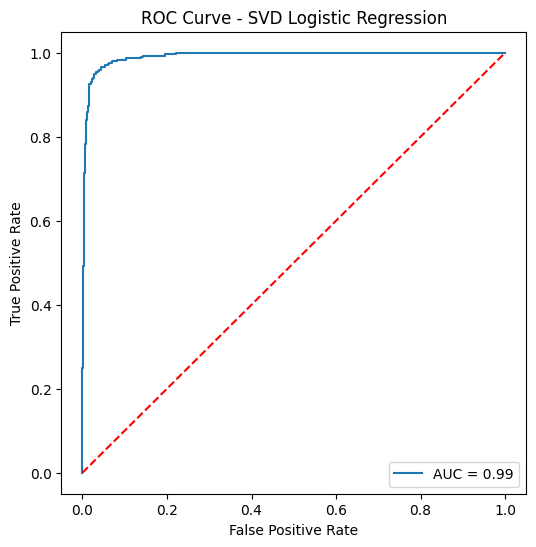

In [17]:
#### YOUR CODE HERE ####
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
import numpy as np
from sklearn.metrics import f1_score, roc_auc_score, classification_report, roc_curve


# Build co-occurrence matrix
def build_cooccurrence_matrix(corpus, window_size=2, max_features=5000):
    vectorizer = CountVectorizer(max_features=max_features, token_pattern=r"(?u)\b\w+\b")
    vectorizer.fit(corpus)
    vocab = vectorizer.get_feature_names_out()
    vocab_to_index = {word: i for i, word in enumerate(vocab)}
    cooccurrence = np.zeros((len(vocab), len(vocab)), dtype=np.int32)

    for text in corpus:
        tokens = text.split()
        for i, word in enumerate(tokens):
            if word in vocab_to_index:
                idx = vocab_to_index[word]
                start, end = max(0, i - window_size), min(len(tokens), i + window_size + 1)
                for j in range(start, end):
                    if i != j and tokens[j] in vocab_to_index:
                        cooccurrence[idx, vocab_to_index[tokens[j]]] += 1
    return cooccurrence, vocab, vocab_to_index

co_matrix_svd, vocab_svd, vocab_to_index_svd = build_cooccurrence_matrix(
    df_processed["text"], window_size=2, max_features=2000
)

# Dimensionality reduction with TruncatedSVD
svd = TruncatedSVD(n_components=500, random_state=42)
word_embeddings_svd = svd.fit_transform(co_matrix_svd)

# Build document vectors (mean pooling of word embeddings)
def document_vector(text, vocab_to_index, word_embeddings):
    tokens = text.split()
    vecs = [word_embeddings[vocab_to_index[w]] for w in tokens if w in vocab_to_index]
    if len(vecs) == 0:
        return np.zeros(word_embeddings.shape[1])
    return np.mean(vecs, axis=0)

X_svd = np.array([document_vector(text, vocab_to_index_svd, word_embeddings_svd) 
                  for text in df_processed["text"]])
y_svd = df_processed["label_num"].values

# Split data into train and test sets
X_train_svd, X_test_svd, y_train_svd, y_test_svd = train_test_split(X_svd, y_svd, test_size=0.2, random_state=42, stratify=y_svd)

# Train classifier (Logistic Regression)
clf_svd = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
clf_svd.fit(X_train_svd, y_train_svd)

y_pred_svd = clf_svd.predict(X_test_svd)
y_proba_svd = clf_svd.predict_proba(X_test_svd)[:, 1]

# Evaluation
f1_svd = f1_score(y_test_svd, y_pred_svd)
roc_auc_svd = roc_auc_score(y_test_svd, y_proba_svd)

print("F1 score:", f1_svd)
print("ROC-AUC:", roc_auc_svd)
print("\nClassification Report:\n", classification_report(y_test_svd, y_pred_svd))

# Plot ROC Curve
fpr_svd, tpr_svd, _ = roc_curve(y_test_svd, y_proba_svd)
plt.figure(figsize=(6,6))
plt.plot(fpr_svd, tpr_svd, label=f"AUC = {roc_auc_svd:.2f}")
plt.plot([0,1], [0,1], linestyle="--", color="red")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVD Logistic Regression")
plt.legend(loc="lower right")
plt.show()
#### END YOUR CODE #####

## Alternative: HashingVectorizer  

For large datasets with a high vocabulary size, using `CountVectorizer` for vectorized data storage can be resource-intensive. An alternative approach is to use `HashingVectorizer`. Unlike `CountVectorizer`, which assigns a unique ID to each word/ngram, `HashingVectorizer` maps multiple words to the same ID using a hashing function.  

The choice between these two methods involves a trade-off between memory usage (e.g., RAM) and model quality. Adjusting the `n_features` parameter helps balance this trade-off to ensure that model performance does not degrade significantly.


F1 Score: 0.9640522875816994
ROC-AUC: 0.9953333333333333

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.98       735
           1       0.95      0.98      0.96       300

    accuracy                           0.98      1035
   macro avg       0.97      0.98      0.97      1035
weighted avg       0.98      0.98      0.98      1035

Confusion Matrix:
 [[718  17]
 [  5 295]]


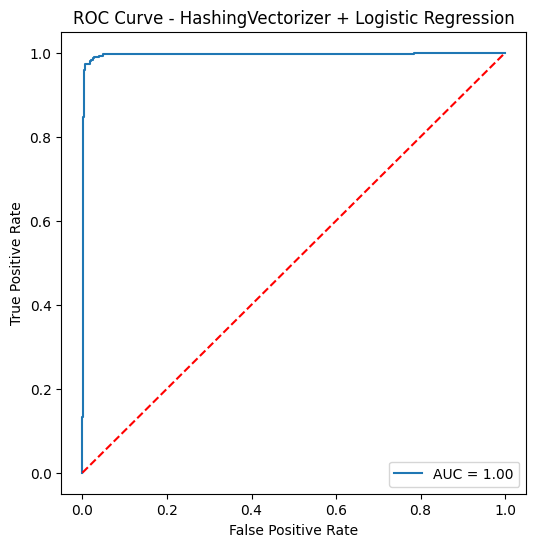

In [21]:
#### YOUR CODE HERE ####
from sklearn.feature_extraction.text import HashingVectorizer

vectorizer_hash = HashingVectorizer(n_features=2**18, alternate_sign=False, norm=None)
X_hash = vectorizer_hash.transform(df_processed["text"])
y_hash = df_processed["label_num"]

# Train-test split
X_train_hash, X_test_hash, y_train_hash, y_test_hash = train_test_split(
    X_hash, y_hash, test_size=0.2, random_state=42, stratify=y_hash
)

# Logistic Regression
clf_hash = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)
clf_hash.fit(X_train_hash, y_train_hash)

# Predictions
y_pred_hash = clf_hash.predict(X_test_hash)
y_prob_hash = clf_hash.predict_proba(X_test_hash)[:, 1]

# Evaluation
f1_hash = f1_score(y_test_hash, y_pred_hash)
roc_auc_hash = roc_auc_score(y_test_hash, y_prob_hash)

print("F1 Score:", f1_hash)
print("ROC-AUC:", roc_auc_hash)
print("\nClassification Report:\n", classification_report(y_test_hash, y_pred_hash))
print("Confusion Matrix:\n", confusion_matrix(y_test_hash, y_pred_hash))

# ROC Curve
fpr_hash, tpr_hash, _ = roc_curve(y_test_hash, y_prob_hash)
plt.figure(figsize=(6, 6))
plt.plot(fpr_hash, tpr_hash, label=f"AUC = {roc_auc_hash:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="red")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - HashingVectorizer + Logistic Regression")
plt.legend(loc="lower right")
plt.show()
#### END YOUR CODE #####


## Comparison and Analysis of Feature Extraction Methods  

                                              Method  F1 Score   ROC-AUC
0            HashingVectorizer + Logistic Regression  0.964052  0.995333
1  Co-occurrence + TruncatedSVD + Logistic Regres...  0.940000  0.991868
2                                         GaussianNB  0.973770  0.986156


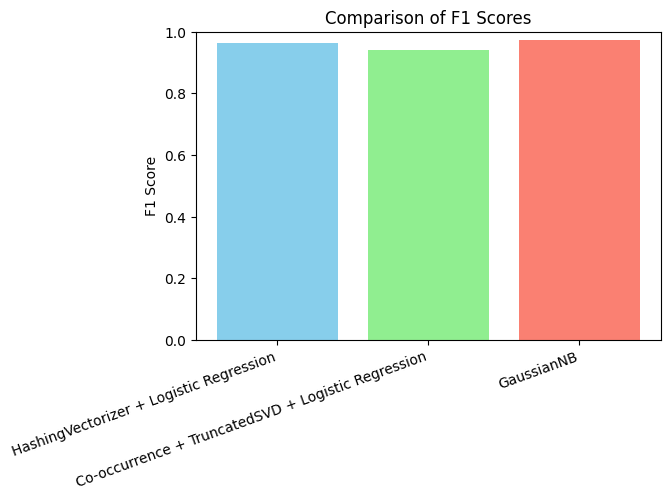

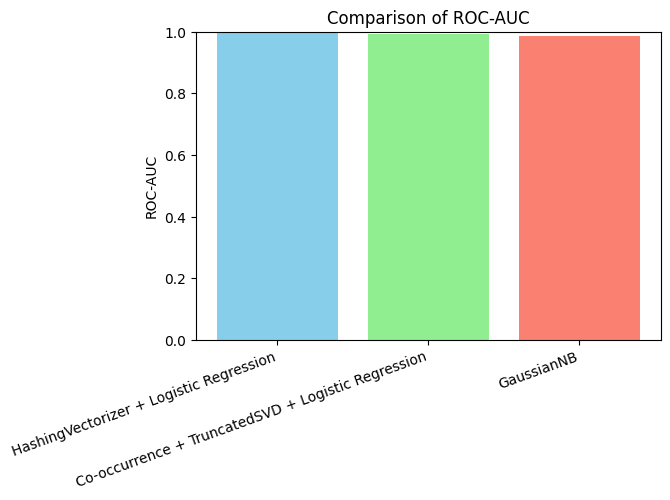

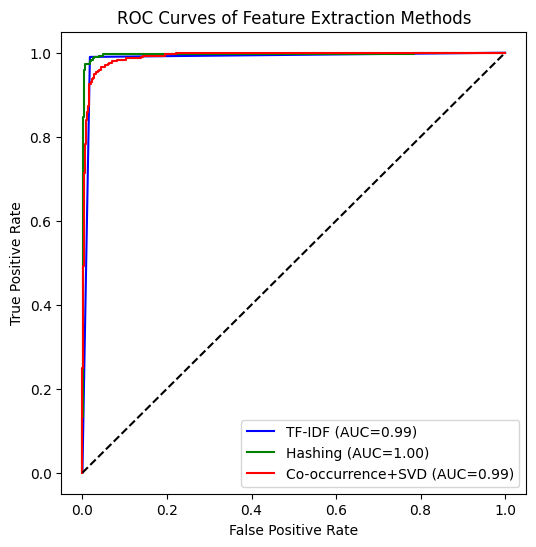

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

results = [
    {"Method": "HashingVectorizer + Logistic Regression", "F1 Score": f1_hash, "ROC-AUC": roc_auc_hash},
    {"Method": "Co-occurrence + TruncatedSVD + Logistic Regression", "F1 Score": f1_svd, "ROC-AUC": roc_auc_svd},
    {"Method": "GaussianNB", "F1 Score": f1_nb, "ROC-AUC": roc_auc_nb},
]

df_results = pd.DataFrame(results)
print(df_results)

# --- Bar chart F1 ---
plt.figure(figsize=(6,4))
plt.bar(df_results["Method"], df_results["F1 Score"], color=["yblue","lightgreen","salmon"])
plt.ylabel("F1 Score")
plt.title("Comparison of F1 Scores")
plt.xticks(rotation=20, ha="right")
plt.ylim(0,1)
plt.show()

# --- Bar chart ROC-AUC ---
plt.figure(figsize=(6,4))
plt.bar(df_results["Method"], df_results["ROC-AUC"], color=["skyblue","lightgreen","salmon"])
plt.ylabel("ROC-AUC")
plt.title("Comparison of ROC-AUC")
plt.xticks(rotation=20, ha="right")
plt.ylim(0,1)
plt.show()

# --- ROC Curve so sánh ---
plt.figure(figsize=(6,6))
plt.plot(fpr_nb, tpr_nb, label=f"TF-IDF (AUC={roc_auc_nb:.2f})", color="blue")
plt.plot(fpr_hash, tpr_hash, label=f"Hashing (AUC={roc_auc_hash:.2f})", color="green")
plt.plot(fpr_svd, tpr_svd, label=f"Co-occurrence+SVD (AUC={roc_auc_svd:.2f})", color="red")
plt.plot([0,1], [0,1], linestyle="--", color="black")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves of Feature Extraction Methods")
plt.legend(loc="lower right")
plt.show()
